Train size: 2670
Test size: 366


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   Temp   No. Observations:                 2670
Model:                 ARIMA(5, 1, 2)   Log Likelihood               -5741.514
Date:                Sun, 14 Jun 2026   AIC                          11499.028
Time:                        22:57:09   BIC                          11546.144
Sample:                             0   HQIC                         11516.077
                               - 2670                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0543      0.157      0.346      0.729      -0.253       0.361
ar.L2          0.4661      0.145      3.216      0.001       0.182       0.750
ar.L3         -0.2797      0.066     -4.253      0.0

/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


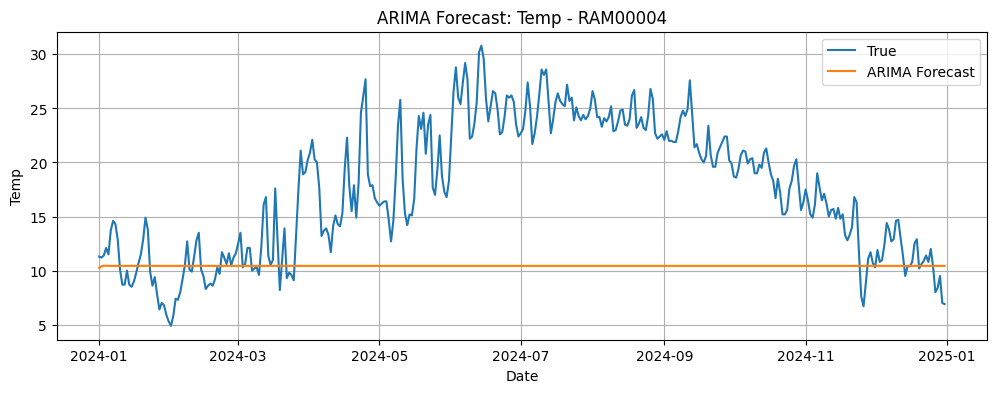

In [1]:
# =====================================================
# ARIMA BASELINE FOR WEATHER DATASET
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# =====================================================
# 1. LOAD DATA
# =====================================================

df = pd.read_excel("final_filled_climate_cleaned.xlsx")

df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

df = df.dropna(subset=["Date"])
df = df.sort_values(["Station", "Date"]).reset_index(drop=True)


# =====================================================
# 2. CHOOSE TARGET VARIABLE
# =====================================================

target = "Temp"      # change to: RH, Rain, PRESS, SUNSHINE
station_name = "RAM00004"   # change station if needed


# =====================================================
# 3. FILTER ONE STATION
# =====================================================

df_station = df[df["Station"] == station_name].copy()

df_station = df_station.sort_values("Date")
df_station = df_station.set_index("Date")

series = df_station[target]


# =====================================================
# 4. CHRONOLOGICAL SPLIT
# =====================================================

train = series[series.index.year <= 2022]
test  = series[series.index.year == 2024]

print("Train size:", len(train))
print("Test size:", len(test))


# =====================================================
# 5. TRAIN ARIMA MODEL
# =====================================================

model = ARIMA(
    train,
    order=(5, 1, 2)
)

model_fit = model.fit()

print(model_fit.summary())


# =====================================================
# 6. FORECAST
# =====================================================

forecast = model_fit.forecast(
    steps=len(test)
)

forecast.index = test.index


# =====================================================
# 7. EVALUATION
# =====================================================

mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)
r2 = r2_score(test, forecast)

print("Target:", target)
print("Station:", station_name)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)


# =====================================================
# 8. PLOT TRUE VS PREDICTED
# =====================================================

plt.figure(figsize=(12, 4))
plt.plot(test.index, test.values, label="True")
plt.plot(forecast.index, forecast.values, label="ARIMA Forecast")
plt.title(f"ARIMA Forecast: {target} - {station_name}")
plt.xlabel("Date")
plt.ylabel(target)
plt.legend()
plt.grid(True)
plt.show()

In [2]:
import pandas as pd
import numpy as np

from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_excel("/Users/mac/Desktop/enve/final enve/fill/final_filled_climate_cleaned.xlsx")

df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

df = df.sort_values(
    ["Station", "Date"]
)

# ==========================================
# TARGETS
# ==========================================

targets = [
    "Temp",
    "RH",
    "Rain",
    "PRESS",
    "SUNSHINE"
]

stations = df["Station"].unique()

results = []

# ==========================================
# LOOP
# ==========================================

for station in stations:

    print("\nProcessing:", station)

    df_station = (
        df[df["Station"] == station]
        .sort_values("Date")
        .set_index("Date")
    )

    for target in targets:

        try:

            series = df_station[target]

            train = series[
                series.index.year <= 2022
            ]

            test = series[
                series.index.year == 2024
            ]

            model = ARIMA(
                train,
                order=(5,1,2)
            )

            model_fit = model.fit()

            forecast = model_fit.forecast(
                steps=len(test)
            )

            mae = mean_absolute_error(
                test,
                forecast
            )

            mse = mean_squared_error(
                test,
                forecast
            )

            rmse = np.sqrt(mse)

            r2 = r2_score(
                test,
                forecast
            )

            results.append({

                "Station": station,
                "Target": target,

                "MAE": mae,
                "MSE": mse,
                "RMSE": rmse,
                "R2": r2

            })

            print(
                target,
                "R2 =",
                round(r2, 3)
            )

        except Exception as e:

            print(
                station,
                target,
                e
            )

# ==========================================
# SAVE RESULTS
# ==========================================

results_df = pd.DataFrame(results)

print(results_df)

results_df.to_excel(
    "ARIMA_All_Stations_Results.xlsx",
    index=False
)

print(
    "\nSaved: ARIMA_All_Stations_Results.xlsx"
)


Processing: HEB00008


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/min

Temp R2 = -0.631


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_

RH R2 = -0.14


...

/opt/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/mini

Rain R2 = -0.07


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_

PRESS R2 = -3.689
SUNSHINE R2 = -3.542
     Station    Target        MAE         MSE       RMSE        R2
0   HEB00008      Temp   6.796412   67.865005   8.238022 -0.630635
1   HEB00008        RH  19.217713  477.202141  21.844957 -0.139665
2   HEB00008      Rain   1.924184   22.178590   4.709415 -0.000646
3   HEB00008     PRESS   3.295443   15.567694   3.945592 -0.612011
4   HEB00008  SUNSHINE   4.678672   21.893473   4.679046  0.000000
5   JEN00001      Temp   7.122623   77.093044   8.780264 -1.032572
6   JEN00001        RH  10.541285  179.291824  13.389990 -0.094434
7   JEN00001      Rain   2.172045   26.737131   5.170796 -0.007062
8   JEN00001     PRESS   4.853886   34.646279   5.886109 -0.752168
9   JEN00001  SUNSHINE   4.507777   24.248511   4.924278 -1.093817
10  JER00005      Temp   7.556196   84.429840   9.188571 -0.817568
11  JER00005        RH   9.955378  162.499197  12.747517 -0.053961
12  JER00005      Rain   0.542241    2.688316   1.639608 -0.002525
13  JER00005     PRESS 

/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [3]:
import pandas as pd
import numpy as np

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# Load data
# =========================

df = pd.read_excel("/Users/mac/Desktop/enve/final enve/fill/final_filled_climate_cleaned.xlsx")

df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

df = df.dropna(subset=["Date"])
df = df.sort_values(["Station", "Date"])

targets = ["Temp", "RH", "Rain", "PRESS", "SUNSHINE"]
stations = df["Station"].unique()

results = []

# =========================
# SARIMA loop
# =========================

for station in stations:
    print("\nStation:", station)

    df_station = (
        df[df["Station"] == station]
        .sort_values("Date")
        .set_index("Date")
    )

    for target in targets:
        print("  Target:", target)

        try:
            series = df_station[target].astype(float)

            train = series[series.index.year <= 2022]
            test = series[series.index.year == 2024]

            # SARIMA model
            model = SARIMAX(
                train,
                order=(2, 1, 2),
                seasonal_order=(1, 1, 1, 7),   # weekly seasonality
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            model_fit = model.fit(disp=False)

            forecast = model_fit.forecast(steps=len(test))
            forecast.index = test.index

            mae = mean_absolute_error(test, forecast)
            mse = mean_squared_error(test, forecast)
            rmse = np.sqrt(mse)
            r2 = r2_score(test, forecast)

            results.append({
                "Station": station,
                "Target": target,
                "MAE": mae,
                "MSE": mse,
                "RMSE": rmse,
                "R2": r2
            })

            print("    R2:", round(r2, 3))

        except Exception as e:
            print("    Error:", e)

# =========================
# Save results
# =========================

sarima_results = pd.DataFrame(results)

print(sarima_results)

sarima_results.to_excel(
    "SARIMA_All_Stations_Results.xlsx",
    index=False
)

print("Saved: SARIMA_All_Stations_Results.xlsx")


Station: HEB00008
  Target: Temp


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get

    R2: -0.11
  Target: RH


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_

    R2: -0.165
  Target: Rain


...

    R2: -0.081
  Target: PRESS


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get

    R2: -4.382
  Target: SUNSHINE


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


    R2: -3.916
     Station    Target        MAE         MSE       RMSE        R2
0   HEB00008      Temp   5.740946   46.177965   6.795437 -0.109547
1   HEB00008        RH  19.390142  487.860954  22.087575 -0.165121
2   HEB00008      Rain   1.600355   22.100338   4.701100  0.002885
3   HEB00008     PRESS   3.338669   15.960308   3.995035 -0.652666
4   HEB00008  SUNSHINE   4.850494   23.545679   4.852389  0.000000
5   JEN00001      Temp   8.212042  100.197399  10.009865 -1.641723
6   JEN00001        RH  11.097606  188.056662  13.713375 -0.147936
7   JEN00001      Rain   1.910760   27.639238   5.257303 -0.041040
8   JEN00001     PRESS   5.150302   39.013027   6.246041 -0.973007
9   JEN00001  SUNSHINE   4.696831   26.295094   5.127874 -1.270536
10  JER00005      Temp   7.874246   92.521527   9.618811 -0.991762
11  JER00005        RH   9.464147  152.260406  12.339384  0.012448
12  JER00005      Rain   0.550958    2.690687   1.640331 -0.003409
13  JER00005     PRESS   7.665527   87.849608  

In [4]:
summary = (
    sarima_results
    .groupby("Target")[["MAE", "RMSE", "R2"]]
    .mean()
    .reset_index()
)

print(summary)

     Target        MAE       RMSE        R2
0     PRESS   5.673914   6.719882 -1.535575
1        RH  13.654811  17.373711 -0.145288
2      Rain   2.114266   4.913470 -0.027468
3  SUNSHINE   5.266885   5.665423 -2.359325
4      Temp   7.109443   8.551378 -0.882118
